In [1]:
import pandas as pd
import numpy as np


In [3]:
customers_df = pd.read_csv("C:/Users/Danush/Downloads/customers.csv")
properties_df = pd.read_csv("C:/Users/Danush/Downloads/properties.csv")


In [5]:
def clean_column_names(df):
    df.columns = (
        df.columns.str.replace("﻿", "", regex=False)  # Removes any hidden special characters
                  .str.strip()                        # Removes extra spaces
                  .str.lower()                        # Converts all to lowercase
                  .str.replace(" ", "_")              # Replaces spaces with underscores
                  .str.replace("#", "number")         # Replaces "#" with "number"
    )
    return df

customers_df = clean_column_names(customers_df)
properties_df = clean_column_names(properties_df)


In [7]:
customers_df['birth_date'] = pd.to_datetime(customers_df['birth_date'], errors='coerce')
properties_df['date_sale'] = properties_df['date_sale'].replace('#num!', np.nan)
properties_df['date_sale'] = pd.to_datetime(properties_df['date_sale'], errors='coerce')


In [9]:
properties_df['price'] = properties_df['price'].replace('[\$,]', '', regex=True).astype(float)


<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\3893243402.py:1: SyntaxWarning: invalid escape sequence '\$'
  properties_df['price'] = properties_df['price'].replace('[\$,]', '', regex=True).astype(float)


In [11]:
for df in [customers_df, properties_df]:
    for col in df.select_dtypes(include='object'):
        df[col] = df[col].astype(str).str.lower().str.strip()


In [13]:
customers_df['sex'] = np.where(customers_df['sex'] == 'm', 1,
                        np.where(customers_df['sex'] == 'f', 0, np.nan))

customers_df['mortgage'] = np.where(customers_df['mortgage'] == 'yes', 1,
                             np.where(customers_df['mortgage'] == 'no', 0, np.nan))


In [15]:
customers_df['customerid'] = customers_df['customerid'].str.strip()
properties_df['customerid'] = properties_df['customerid'].str.strip()


In [17]:
properties_df = properties_df[properties_df['customerid'].notna()]


In [19]:
merged_df = pd.merge(properties_df, customers_df, on='customerid', how='inner')


In [21]:
merged_df = merged_df.dropna()


In [23]:
merged_df.to_csv("cleaned_real_estate_data.csv", index=False)


In [25]:
# USING THE CLEANED DATASET FOR FURTHER ANALYSIS 

In [27]:
import pandas as pd
import numpy as np

# Load cleaned data
merged_df = pd.read_csv("cleaned_real_estate_data.csv")


In [29]:
# General descriptive statistics for numerical columns
desc_stats = merged_df.describe()
print(desc_stats)


       unnamed:_0_x           id    building  propertynumber         area  \
count    178.000000   178.000000  178.000000      178.000000   178.000000   
mean      88.500000  2730.398876    2.702247       28.151685   905.008596   
std       51.528309  1210.397158    1.210171       14.780294   259.384449   
min        0.000000  1002.000000    1.000000        1.000000   579.750000   
25%       44.250000  2015.250000    2.000000       16.000000   738.245000   
50%       88.500000  3006.500000    3.000000       28.000000   792.530000   
75%      132.750000  3053.750000    3.000000       40.000000  1084.230000   
max      177.000000  5051.000000    5.000000       59.000000  1942.500000   

               price  unnamed:_0_y         sex  deal_satisfaction    mortgage  
count     178.000000    178.000000  178.000000         178.000000  178.000000  
mean   270965.425730     76.601124    0.606742           3.522472    0.325843  
std     78525.152444     47.216216    0.489851           1.315724 

In [37]:
print(merged_df)

     unnamed:_0_x    id  building   date_sale       type  propertynumber  \
0               0  1030         1  2005-11-01  apartment              30   
1               1  1029         1  2005-10-01  apartment              29   
2               2  2002         2  2007-07-01  apartment               2   
3               3  2031         2  2007-12-01  apartment              31   
4               4  1049         1  2004-11-01  apartment              49   
..            ...   ...       ...         ...        ...             ...   
173           173  3040         3  2007-06-01  apartment              40   
174           174  1023         1  2005-04-01  apartment              23   
175           175  3009         3  2006-05-01  apartment               9   
176           176  3052         3  2006-03-01  apartment              52   
177           177  3025         3  2007-06-01  apartment              25   

        area      price status customerid  ...        name     surname  \
0     743.09 

In [39]:
# Convert status to a binary 'sold' column (1 = sold, 0 = not sold)
merged_df['sold'] = merged_df['status'].str.lower().str.strip().apply(lambda x: 1 if x == 'sold' else 0)


In [41]:
# Convert 'mortgage' to numeric (should already be 0/1, but we'll enforce it)
merged_df['mortgage'] = pd.to_numeric(merged_df['mortgage'], errors='coerce')


In [43]:
# Group by building and get total sold and mortgage
building_totals = merged_df.groupby('building')[['sold', 'mortgage']].sum()
print("\n🏢 Total properties sold and with mortgage by building type:")
print(building_totals)



🏢 Total properties sold and with mortgage by building type:
          sold  mortgage
building                
1           31      11.0
2           52      17.0
3           53      15.0
4           23       9.0
5           19       6.0


In [45]:
building_averages = merged_df.groupby('building')[['area', 'price', 'deal_satisfaction']].mean()
print("\n📊 Average area, price, and deal satisfaction by building type:")
print(building_averages)



📊 Average area, price, and deal satisfaction by building type:
                area          price  deal_satisfaction
building                                              
1         982.431935  291956.628387           3.225806
2         915.506538  276263.472308           3.500000
3         870.257170  259241.115660           3.566038
4         933.577826  274722.053913           3.869565
5         812.309474  250373.861579           3.526316


In [47]:
print(merged_df['building'].unique())


[1 2 3 4 5]


In [49]:
# Mapping dictionary
building_map = {
    1: 'Apartment',
    2: 'Villa',
    3: 'Duplex',
    4: 'Studio',
    5: 'Penthouse'
}

# Apply the mapping
merged_df['building'] = merged_df['building'].map(building_map)


In [51]:
# Group by building with updated labels
building_totals = merged_df.groupby('building')[['sold', 'mortgage']].sum()
building_averages = merged_df.groupby('building')[['area', 'price', 'deal_satisfaction']].mean()

print("\n🏢 Total properties sold and with mortgage by building type:")
print(building_totals)

print("\n📊 Average area, price, and deal satisfaction by building type:")
print(building_averages)



🏢 Total properties sold and with mortgage by building type:
           sold  mortgage
building                 
Apartment    31      11.0
Duplex       53      15.0
Penthouse    19       6.0
Studio       23       9.0
Villa        52      17.0

📊 Average area, price, and deal satisfaction by building type:
                 area          price  deal_satisfaction
building                                               
Apartment  982.431935  291956.628387           3.225806
Duplex     870.257170  259241.115660           3.566038
Penthouse  812.309474  250373.861579           3.526316
Studio     933.577826  274722.053913           3.869565
Villa      915.506538  276263.472308           3.500000


In [59]:
#BREAKDOWN BY COUNTRY

In [53]:
country_totals = merged_df.groupby('country')[['sold', 'mortgage']].sum()
print("🌍 Total properties sold and with mortgage by country:")
print(country_totals)


🌍 Total properties sold and with mortgage by country:
         sold  mortgage
country                
belgium     2       0.0
canada      7       0.0
denmark     1       0.0
germany     1       0.0
mexico      1       0.0
russia      4       1.0
uk          2       0.0
usa       160      57.0


In [55]:
country_averages = merged_df.groupby('country')[['area', 'price', 'deal_satisfaction']].mean()
print("\n📊 Average area, price, and deal satisfaction by country:")
print(country_averages)



📊 Average area, price, and deal satisfaction by country:
                area          price  deal_satisfaction
country                                               
belgium   852.730000  229075.470000            3.00000
canada    917.382857  274069.384286            5.00000
denmark   785.480000  257183.480000            1.00000
germany   743.410000  205098.210000            5.00000
mexico   1283.450000  338181.180000            3.00000
russia    903.757500  278828.835000            2.50000
uk        739.480000  220142.680000            4.00000
usa       906.612875  271869.659875            3.49375


In [61]:
# BREAKDOWN BY STATE-FREQUENCY

In [63]:
# Frequency count by state
state_freq = merged_df['state'].value_counts().sort_index()
print("\n📌 Frequency of entries by state:")
print(state_freq)



📌 Frequency of entries by state:
state
arizona        11
california    106
colorado       11
kansas          1
nevada         14
oregon         11
utah            5
virginia        4
wyoming         1
Name: count, dtype: int64


In [65]:
# Convert to DataFrame for better formatting
state_freq_df = state_freq.to_frame(name='Frequency')

# Relative frequency
state_freq_df['Relative Frequency (%)'] = (state_freq_df['Frequency'] / state_freq_df['Frequency'].sum()) * 100

# Cumulative frequency
state_freq_df['Cumulative Frequency'] = state_freq_df['Frequency'].cumsum()

print("\n📌 Relative and Cumulative Frequency by State:")
print(state_freq_df)



📌 Relative and Cumulative Frequency by State:
            Frequency  Relative Frequency (%)  Cumulative Frequency
state                                                              
arizona            11                6.707317                    11
california        106               64.634146                   117
colorado           11                6.707317                   128
kansas              1                0.609756                   129
nevada             14                8.536585                   143
oregon             11                6.707317                   154
utah                5                3.048780                   159
virginia            4                2.439024                   163
wyoming             1                0.609756                   164


In [75]:
print(merged_df.columns)


Index(['unnamed:_0_x', 'id', 'building', 'date_sale', 'type', 'propertynumber',
       'area', 'price', 'status', 'customerid', 'unnamed:_0_y', 'entity',
       'name', 'surname', 'birth_date', 'sex', 'country', 'state', 'purpose',
       'deal_satisfaction', 'mortgage', 'source', 'sold'],
      dtype='object')


In [77]:
merged_df['birth_date'] = pd.to_datetime(merged_df['birth_date'])
merged_df['date_sale'] = pd.to_datetime(merged_df['date_sale'])


In [79]:
merged_df['age'] = (merged_df['date_sale'] - merged_df['birth_date']).dt.days // 365


In [81]:
bins = [19, 25, 31, 36, 42, 48, 54, 59, 65, 71, 76]
labels = ["(19,25]", "(25,31]", "(31,36]", "(36,42]", "(42,48]", "(48,54]", "(54,59]", "(59,65]", "(65,71]", "(71,76]"]

merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=True)


In [83]:
age_group_counts = merged_df.groupby('age_group')['id'].count()
print(age_group_counts)


age_group
(19,25]     8
(25,31]    17
(31,36]    23
(36,42]    32
(42,48]    30
(48,54]    17
(54,59]    24
(59,65]    11
(65,71]    11
(71,76]     4
Name: id, dtype: int64


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\367297610.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_counts = merged_df.groupby('age_group')['id'].count()


In [85]:
merged_df['price_group'] = pd.cut(merged_df['price'], bins=10)


In [87]:
price_group_counts = merged_df.groupby('price_group')['id'].count()
print(price_group_counts)


price_group
(153116.386, 188499.062]     7
(188499.062, 223531.414]    49
(223531.414, 258563.766]    51
(258563.766, 293596.118]    17
(293596.118, 328628.47]     18
(328628.47, 363660.822]     10
(363660.822, 398693.174]    10
(398693.174, 433725.526]     5
(433725.526, 468757.878]     7
(468757.878, 503790.23]      4
Name: id, dtype: int64


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\2647210740.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_group_counts = merged_df.groupby('price_group')['id'].count()


In [89]:
covariance = merged_df['age'].cov(merged_df['price'])
correlation = merged_df['age'].corr(merged_df['price'])

print(f"Covariance between age and price: {covariance}")
print(f"Correlation between age and price: {correlation}")


Covariance between age and price: -179316.77016187386
Correlation between age and price: -0.1762504286382635


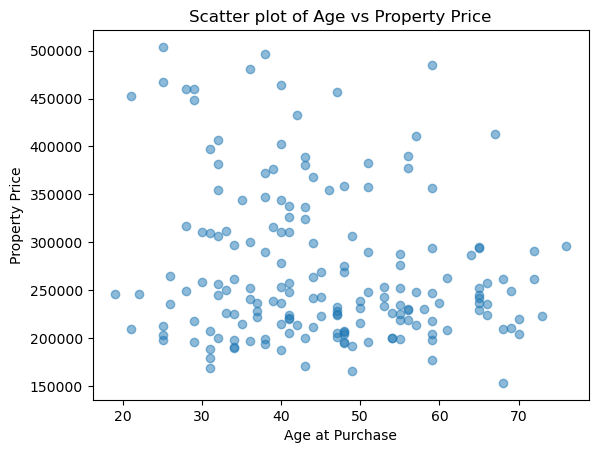

In [91]:
import matplotlib.pyplot as plt

plt.scatter(merged_df['age'], merged_df['price'], alpha=0.5)
plt.xlabel('Age at Purchase')
plt.ylabel('Property Price')
plt.title('Scatter plot of Age vs Property Price')
plt.show()


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\3188052595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_satisfaction.values, y=country_satisfaction.index, palette='Blues_d')


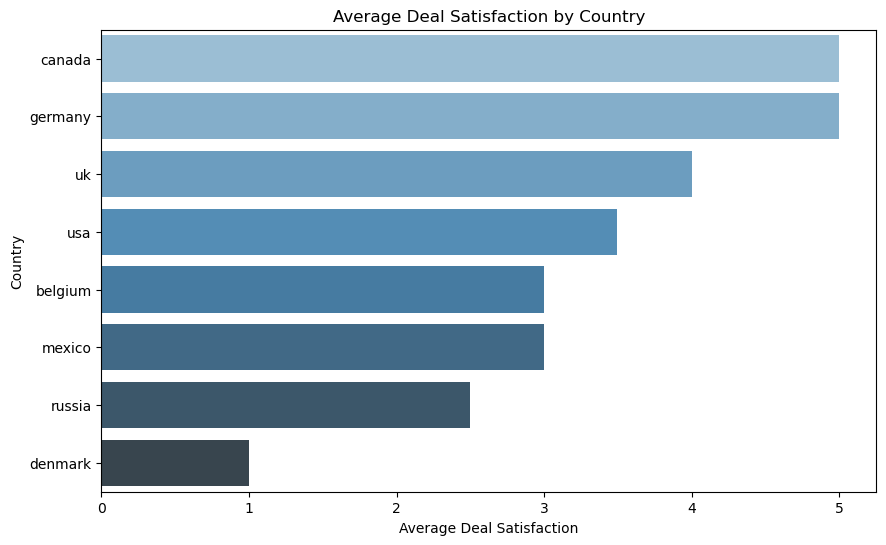

In [97]:
#1. Average Deal Satisfaction per Country and State
#🔹 By Country – Bar Chart:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and plot
country_satisfaction = merged_df.groupby('country')['deal_satisfaction'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_satisfaction.values, y=country_satisfaction.index, palette='Blues_d')
plt.title('Average Deal Satisfaction by Country')
plt.xlabel('Average Deal Satisfaction')
plt.ylabel('Country')
plt.show()


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\3645916337.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_satisfaction.index, y=state_satisfaction.values, palette='Greens_d')


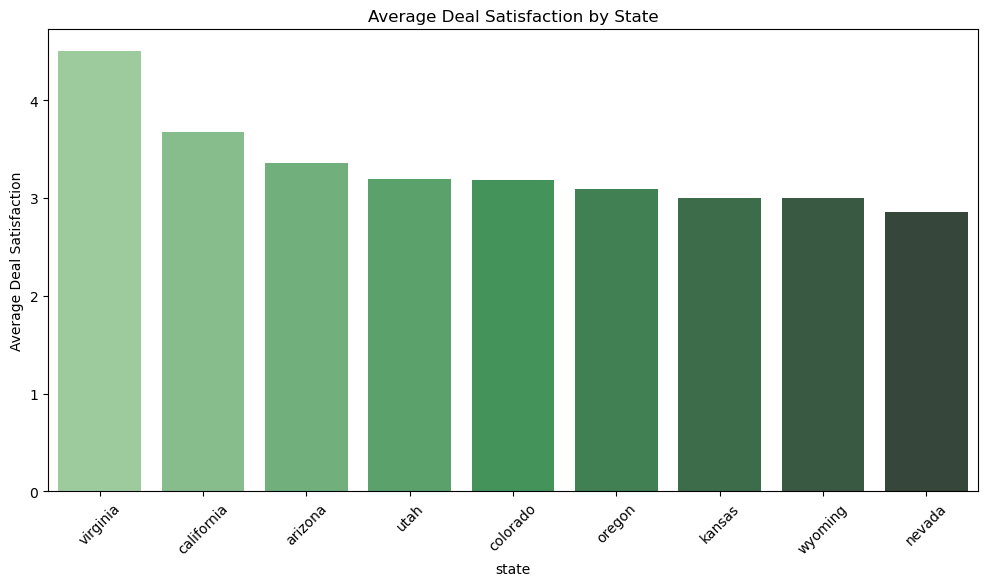

In [99]:
#🔹 By State – Bar Chart:
state_satisfaction = merged_df.groupby('state')['deal_satisfaction'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_satisfaction.index, y=state_satisfaction.values, palette='Greens_d')
plt.title('Average Deal Satisfaction by State')
plt.ylabel('Average Deal Satisfaction')
plt.xticks(rotation=45)
plt.show()


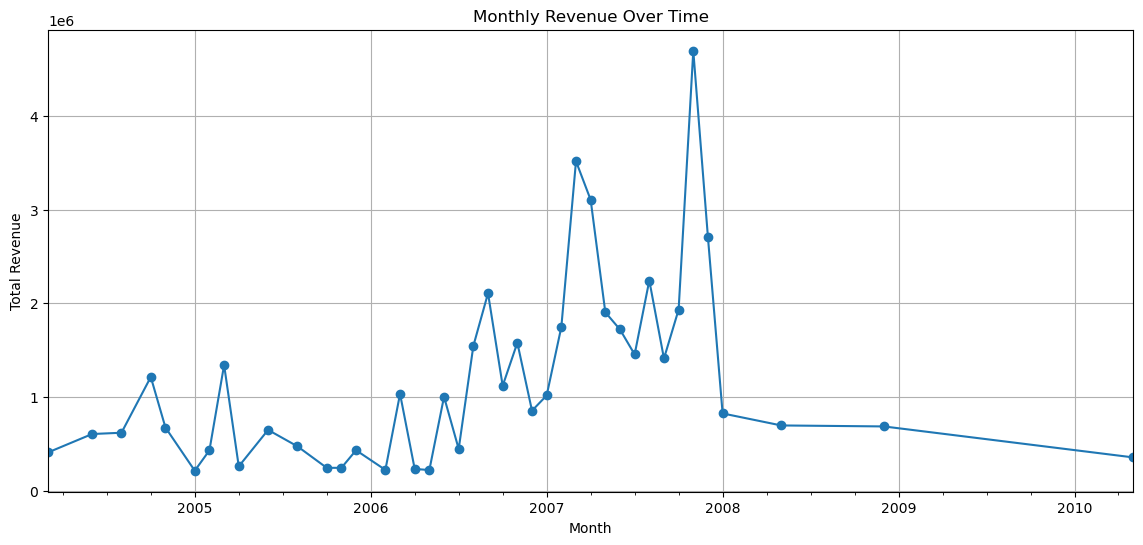

In [103]:
#Monthly Revenue of the Company
#Extract Year-Month from date_sale and sum prices:
merged_df['year_month'] = merged_df['date_sale'].dt.to_period('M')

monthly_revenue = merged_df.groupby('year_month')['price'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()


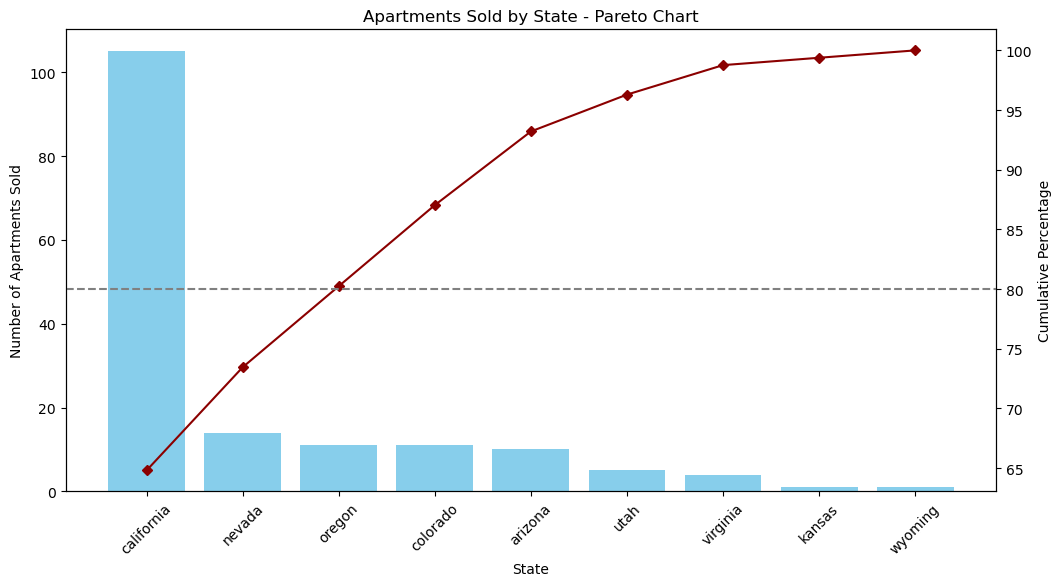

In [105]:
#Apartments Sold in Each State – Pareto Chart
#Filter for apartments (type == 'apartment') and create Pareto chart:
apartments = merged_df[merged_df['type'].str.lower() == 'apartment']

state_counts = apartments['state'].value_counts().sort_values(ascending=False)
cum_percent = state_counts.cumsum() / state_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar
ax1.bar(state_counts.index, state_counts.values, color='skyblue')
ax1.set_ylabel('Number of Apartments Sold')
ax1.set_xlabel('State')
ax1.set_title('Apartments Sold by State - Pareto Chart')
ax1.tick_params('x', rotation=45)

# Line for cumulative %
ax2 = ax1.twinx()
ax2.plot(state_counts.index, cum_percent.values, color='darkred', marker='D', ms=5)
ax2.set_ylabel('Cumulative Percentage')
ax2.axhline(80, color='gray', linestyle='--')
plt.show()


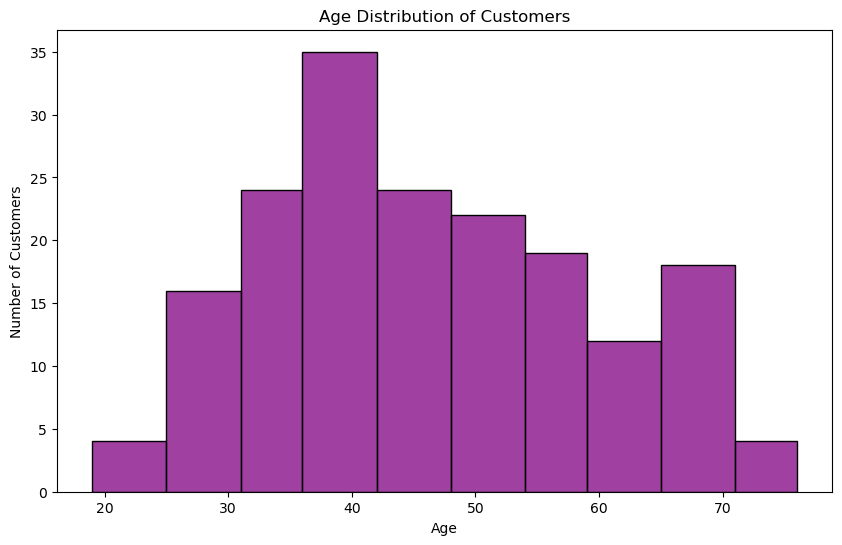

In [109]:
#Age Distribution of Customers – Histogram with the same bins
#Use the previously created age and age_group:
plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x='age', bins=[19, 25, 31, 36, 42, 48, 54, 59, 65, 71, 76], kde=False, color='purple')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(False)
plt.show()


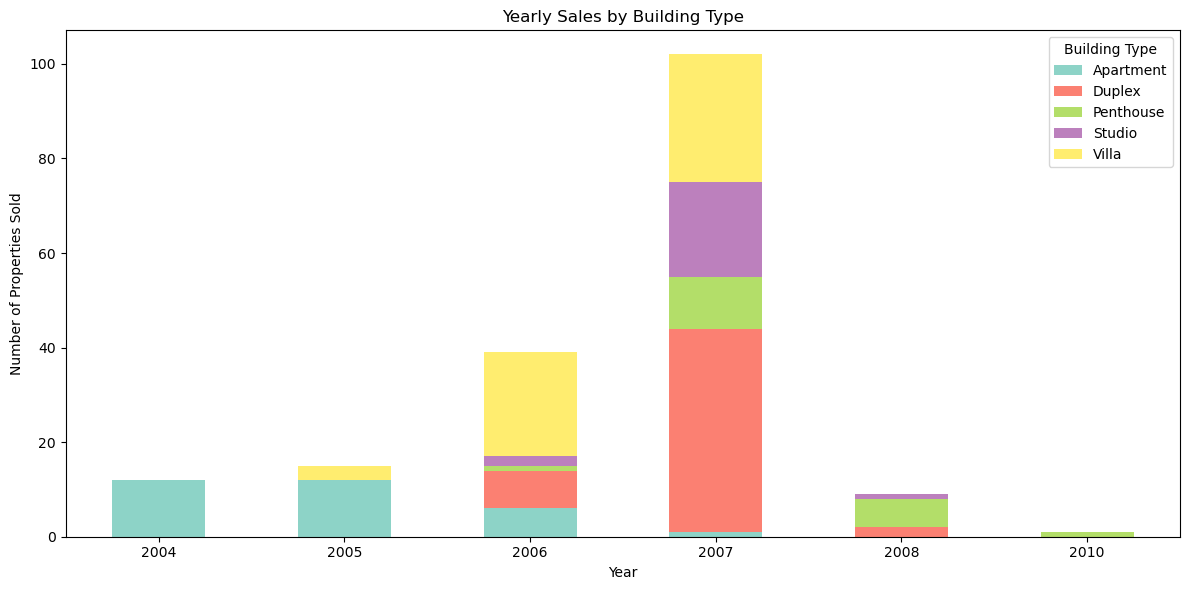

In [111]:
#Yearly Sales for Each Building Type – Stacked Bar or Line Plot
#Extract year, then group by year and building:
merged_df['year'] = merged_df['date_sale'].dt.year

yearly_sales = merged_df.groupby(['year', 'building'])['id'].count().unstack().fillna(0)

# Stacked bar chart
yearly_sales.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')
plt.title('Yearly Sales by Building Type')
plt.xlabel('Year')
plt.ylabel('Number of Properties Sold')
plt.xticks(rotation=0)
plt.legend(title='Building Type')
plt.tight_layout()
plt.show()


In [113]:
#DATA INTERPRETATION

C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\213713202.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='age_group', palette='viridis', order=labels)


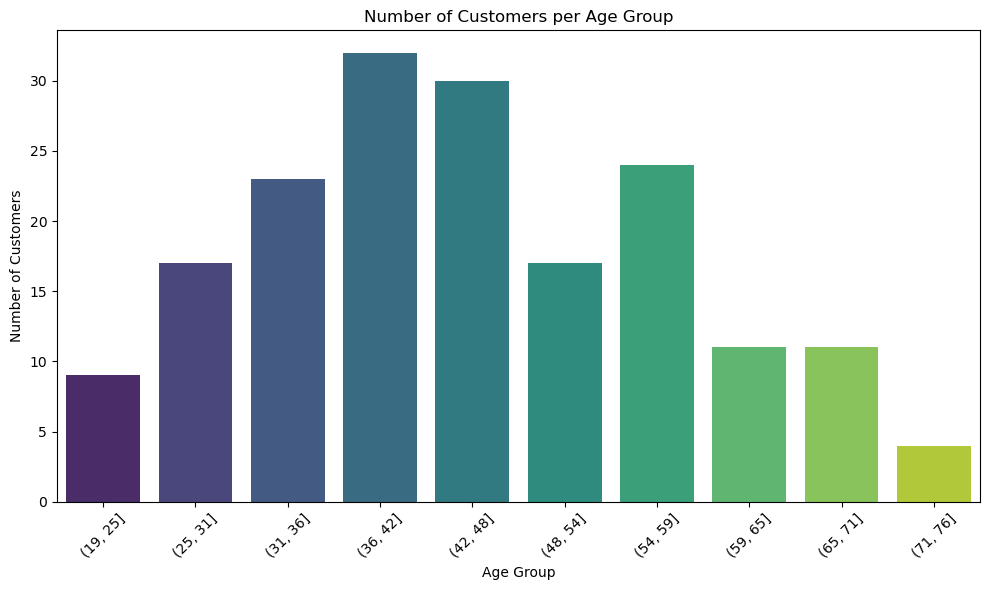

In [125]:
#1 🔹 Which customer age bracket has the most buyer potential?
# Convert to datetime
merged_df['birth_date'] = pd.to_datetime(merged_df['birth_date'])
merged_df['date_sale'] = pd.to_datetime(merged_df['date_sale'])

# Calculate age
merged_df['age'] = (merged_df['date_sale'] - merged_df['birth_date']).dt.days // 365

bins = [19, 25, 31, 36, 42, 48, 54, 59, 65, 71, 76]
labels = ['(19, 25]', '(25, 31]', '(31, 36]', '(36, 42]', '(42, 48]',
          '(48, 54]', '(54, 59]', '(59, 65]', '(65, 71]', '(71, 76]']

merged_df['age_group'] = pd.cut(merged_df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=merged_df, x='age_group', palette='viridis', order=labels)
plt.title('Number of Customers per Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Insight:
#The age group with the highest number of property buyers represents the strongest market segment. If (25, 31] or (31, 36]
#has the most buyers, it suggests that young professionals or early families are the key target group for future real estate marketing.


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\2607506864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=building_counts.index, y=building_counts.values, palette='coolwarm')


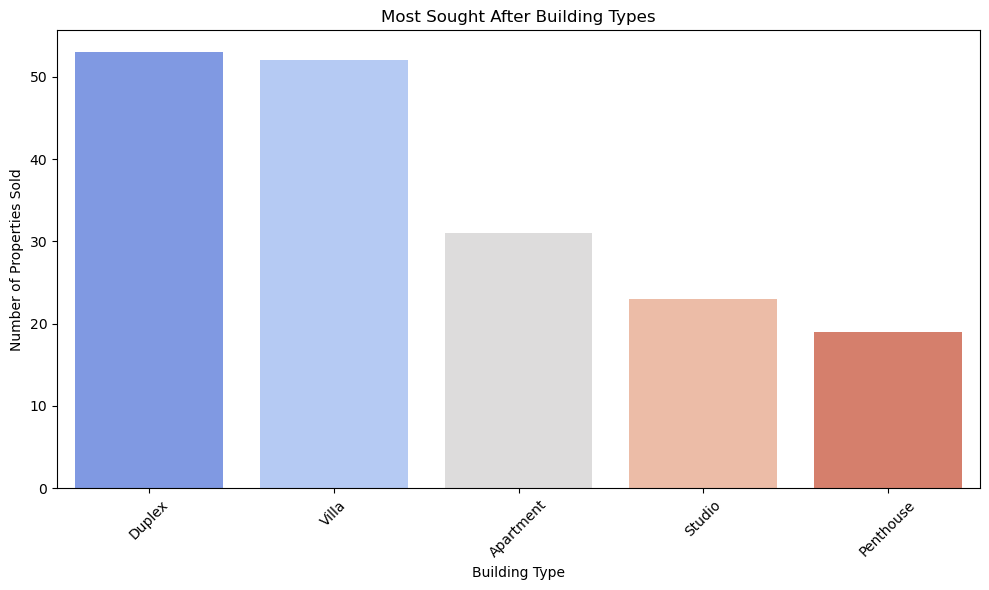

Most Sought-After Building Type: Duplex


In [131]:
# 2. What is the most sought-after building?
building_counts = merged_df['building'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=building_counts.index, y=building_counts.values, palette='coolwarm')
plt.title('Most Sought After Building Types')
plt.xlabel('Building Type')
plt.ylabel('Number of Properties Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

most_sought_building = building_counts.idxmax()
print("Most Sought-After Building Type:", most_sought_building)

#Insight:
#The building type with the highest count is the most popular among customers. For example, 
#if "Duplex" is the most frequent, it means more people prefer compact, affordable urban homes.


C:\Users\Danush\AppData\Local\Temp\ipykernel_28352\3037949642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=building_avg_price.index, y=building_avg_price.values, palette='magma')


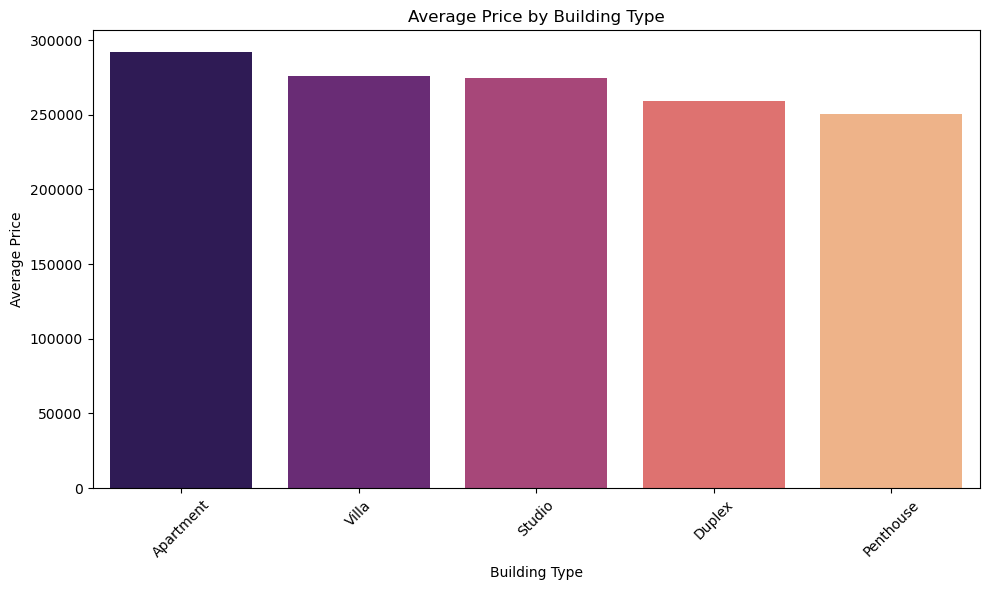

Highest Priced Building Type: Apartment


In [133]:
#3. What is the highest priced building?
building_avg_price = merged_df.groupby('building')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=building_avg_price.index, y=building_avg_price.values, palette='magma')
plt.title('Average Price by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

highest_priced_building = building_avg_price.idxmax()
print("Highest Priced Building Type:", highest_priced_building)

# Insight:
#This helps identify luxury property types. For this instance, "apartment" has the highest average price, 
#it’s likely a premium option for high-income buyers.

Correlation between Age and Price: -0.1762504286382635


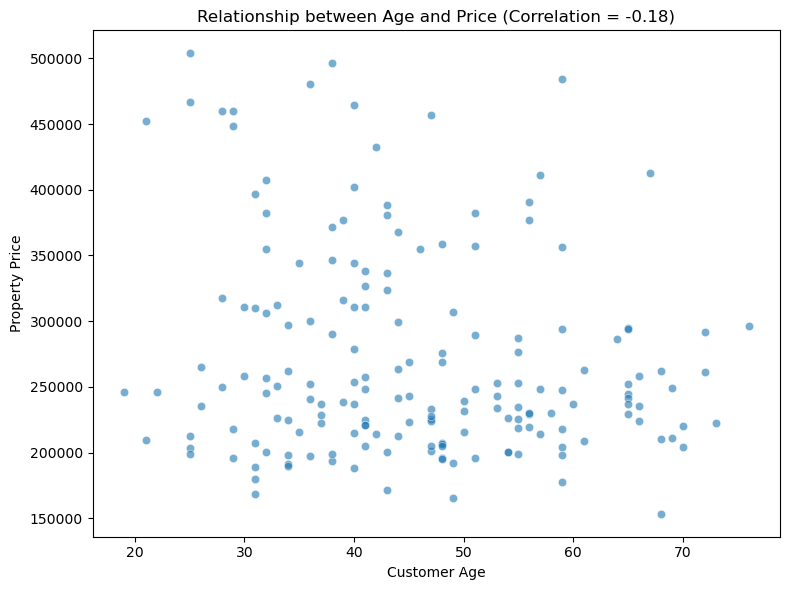

In [137]:
#4. What is the relationship between age and price?
correlation = merged_df['age'].corr(merged_df['price'])
print("Correlation between Age and Price:", correlation)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged_df, x='age', y='price', alpha=0.6)
plt.title(f'Relationship between Age and Price (Correlation = {correlation:.2f})')
plt.xlabel('Customer Age')
plt.ylabel('Property Price')
plt.tight_layout()
plt.show()

#INSIGHTS
#Correlation close to 0: Little to no linear relationship.
#Positive correlation: Older customers buy more expensive properties.
#Negative correlation: Younger customers spend more (rare).